[]

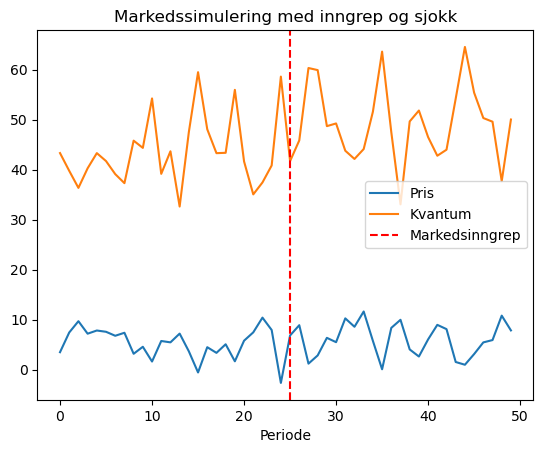

In [7]:
import numpy as np
import matplotlib.pyplot as plt

a, b, c, d = 50, 1, 40, 1
perioder = 50
std_sjokk = 5
skatt = 0.1
subsidie = 0.1

priser = []
kvantum = []

for i in range(perioder):
    e_s = np.random.normal(0, std_sjokk)
    e_d = np.random.normal(0, std_sjokk)
    P = (a - c + e_d - e_s) / (b + d)
    Q = a - b * P + e_s

    if i == perioder // 2:
        a += skatt * a
        c += subsidie * c

    priser.append(P)
    kvantum.append(Q)

plt.plot(priser, label = 'Pris')
plt.plot(kvantum, label = 'Kvantum')

inngrep_tidspunkt = perioder // 2
plt.axvline(x = inngrep_tidspunkt, color = 'red', linestyle = '--', label = 'Markedsinngrep')
plt.xlabel('Periode')
plt.title('Markedssimulering med inngrep og sjokk')
plt.legend()
plt.plot()

Uganda Har startpopulasjon 4000000.0
Burkina Faso Har startpopulasjon 8000000.0
Bahrain Har startpopulasjon 6000000.0


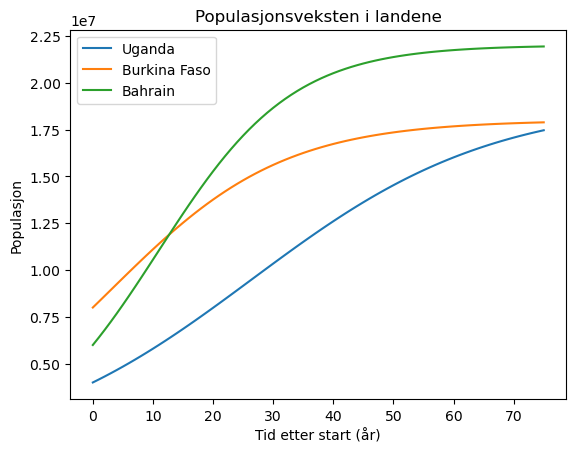

In [1]:
import math
import matplotlib.pyplot as plt

land = ["Uganda", "Burkina Faso", "Bahrain"]
K = [19e6, 18e6, 22e6]
r = [0.05, 0.07, 0.09]
P0 = [4e6, 8e6, 6e6]
t = 75
t_liste = list(range(0,t+1))

def logistisk_vekst(P0,K,r,t):
    A = (K-P0)/P0
    P = K/(1+A*math.exp(-r*t))
    return P
  
def lag_pop_funk(P0,K,r):
    def slutt_populasjon(t):
        P = logistisk_vekst(P0,K,r,t)
        return P
    return slutt_populasjon

def format_pop(P):
    return int(round(P,-3))


data = []
n_indeks = len(land)
for i in range(n_indeks):
    datapunkt = [land[i],P0[i], K[i], r[i]]
    #print(datapunkt)
    data.append(datapunkt)

for datapunkt in data:
    print(datapunkt[0], "Har startpopulasjon", datapunkt[1])
    pop_vekst = []
    for t_i in t_liste:
        populasjon = logistisk_vekst(datapunkt[1], datapunkt[2], datapunkt[3], t_i)
        pop_vekst.append(populasjon)
    datapunkt.append(pop_vekst)

for d in data:
    plt.plot(t_liste, d[-1], label=d[0])
plt.title("Populasjonsveksten i landene")
plt.xlabel("Tid etter start (år)")
plt.ylabel("Populasjon")
plt.legend()
plt.show()

Hei, velkommen til Platons aksjesparekalkulator


Hva er ditt startbeløp:  1
Hvor mange år tenker du å spare:  1
Antall innskudd per år:  1
Innskuddsbeløp:  1


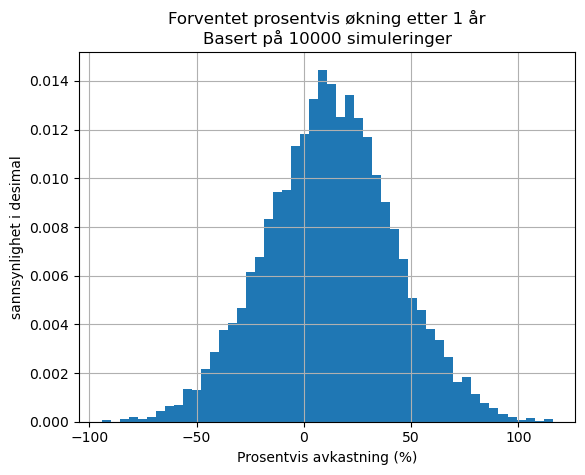

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import random as random

print("Hei, velkommen til Platons aksjesparekalkulator")

def platon_kalkulator(start_investering, antall_aar, innskudd_per_aar, innskudd_belop, avkastning, standardavvik, simuleringer):

    slutt_verdier = []
    total_innskudd = innskudd_belop*innskudd_per_aar*antall_aar
  
    for simulering in range(simuleringer):
    
        saldo = start_investering

        for aar in range(antall_aar):
         
            årlig_avkastning = np.random.normal(avkastning, standardavvik)
  
            saldo += innskudd_per_aar * innskudd_belop
  
            saldo *= (1 + årlig_avkastning)

        saldo_uten_innskudd = saldo - total_innskudd
       
        prosentvis_økning = (saldo_uten_innskudd - start_investering) / start_investering * 100
        slutt_verdier.append(prosentvis_økning)

    return slutt_verdier

start_investering = float(input("Hva er ditt startbeløp: "))
antall_aar = int(input("Hvor mange år tenker du å spare: "))
innskudd_per_aar = int(input("Antall innskudd per år: "))
innskudd_belop = float(input("Innskuddsbeløp: "))
avkastning = round(random.uniform(-0.03, 0.13), 3)
standardavvik = (0.15)
simuleringer = 10000

slutt_verdier = platon_kalkulator(start_investering, antall_aar, innskudd_per_aar, innskudd_belop, avkastning, standardavvik, simuleringer)
3
3.0
plt.hist(slutt_verdier, bins = 50, density = True,)
plt.title(f'Forventet prosentvis økning etter {antall_aar} år\nBasert på {simuleringer} simuleringer')
plt.xlabel('Prosentvis avkastning (%)')
plt.ylabel('sannsynlighet i desimal')
plt.grid(True)
plt.show()